# **ACF AND PACF PLOT**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Matplotlib is building the font cache; this may take a moment.


In [2]:
dataset = sm.datasets.get_rdataset("AirPassengers")
df = dataset.data

In [3]:
# Setup the index as a proper datetime object for Time Series analysis
df['time'] = pd.date_range(start='1949-01-01', periods=len(df), freq='M')
df.set_index('time', inplace=True)
ts_data = df['value']

/var/folders/lj/nvsz1xgn6qzbwb80_ns_hx9c0000gn/T/ipykernel_45625/851817093.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df['time'] = pd.date_range(start='1949-01-01', periods=len(df), freq='M')


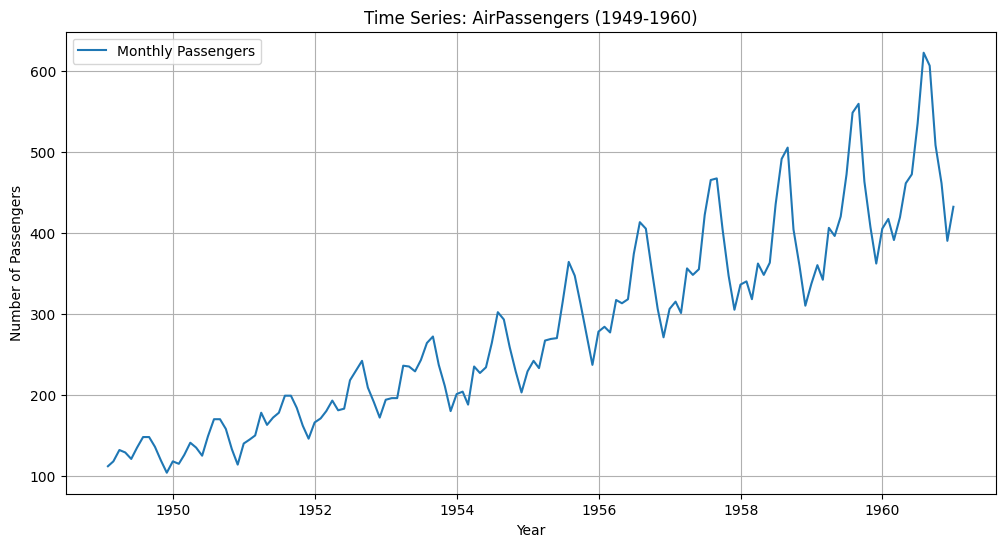

In [4]:
# --- 2. Plot the Original Time Series ---
plt.figure(figsize=(12, 6))
plt.plot(ts_data, label='Monthly Passengers')
plt.title('Time Series: AirPassengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)
plt.show()

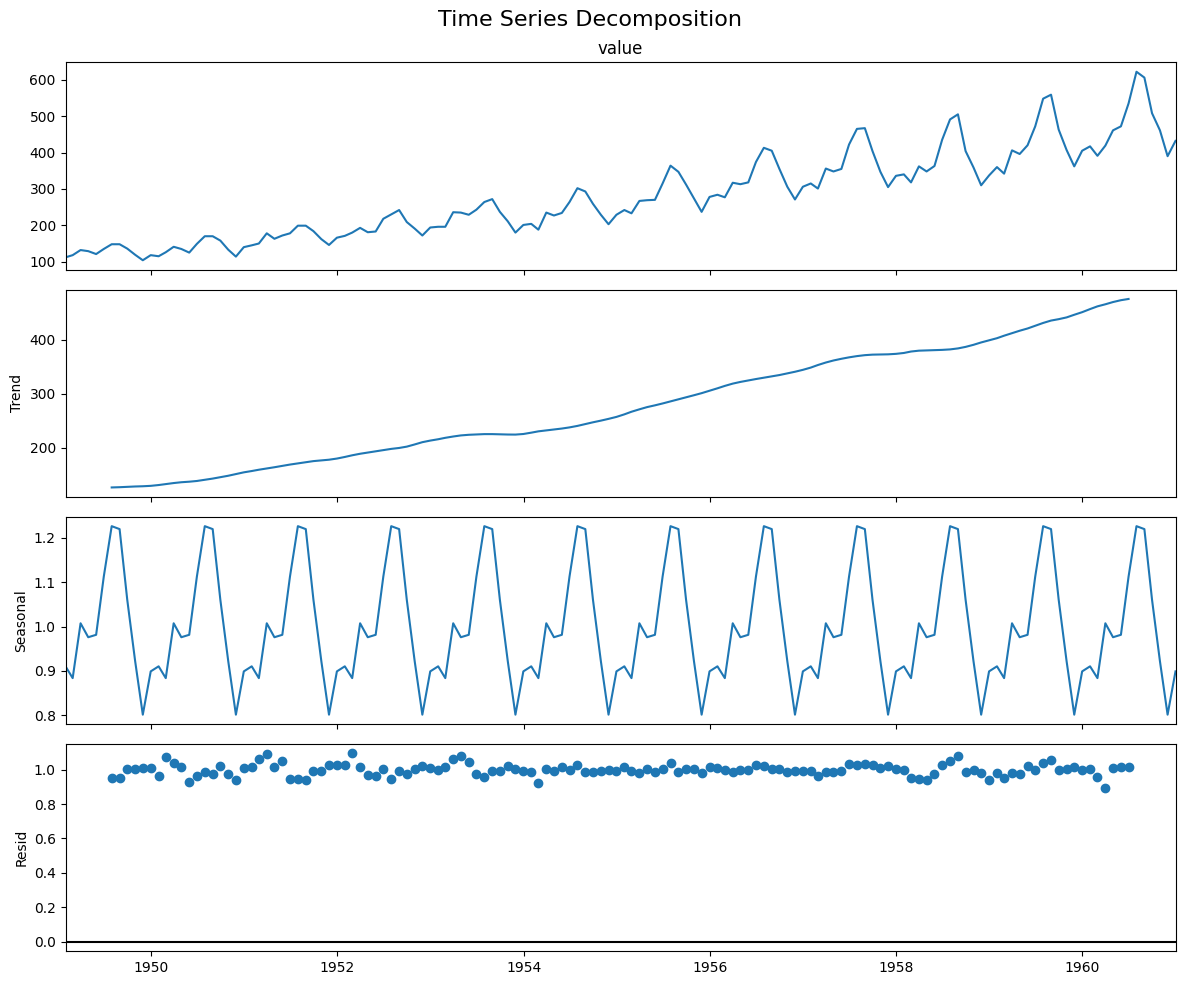

In [5]:
# --- 3. Decomposition (Trend, Seasonality, Irregular) ---
# We use a 'multiplicative' model because the amplitude of the seasonality 
# increases as the trend increases. If it were constant, we would use 'additive'.
decomposition = seasonal_decompose(ts_data, model='multiplicative')

fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Time Series Decomposition', fontsize=16)
plt.tight_layout()
plt.show()

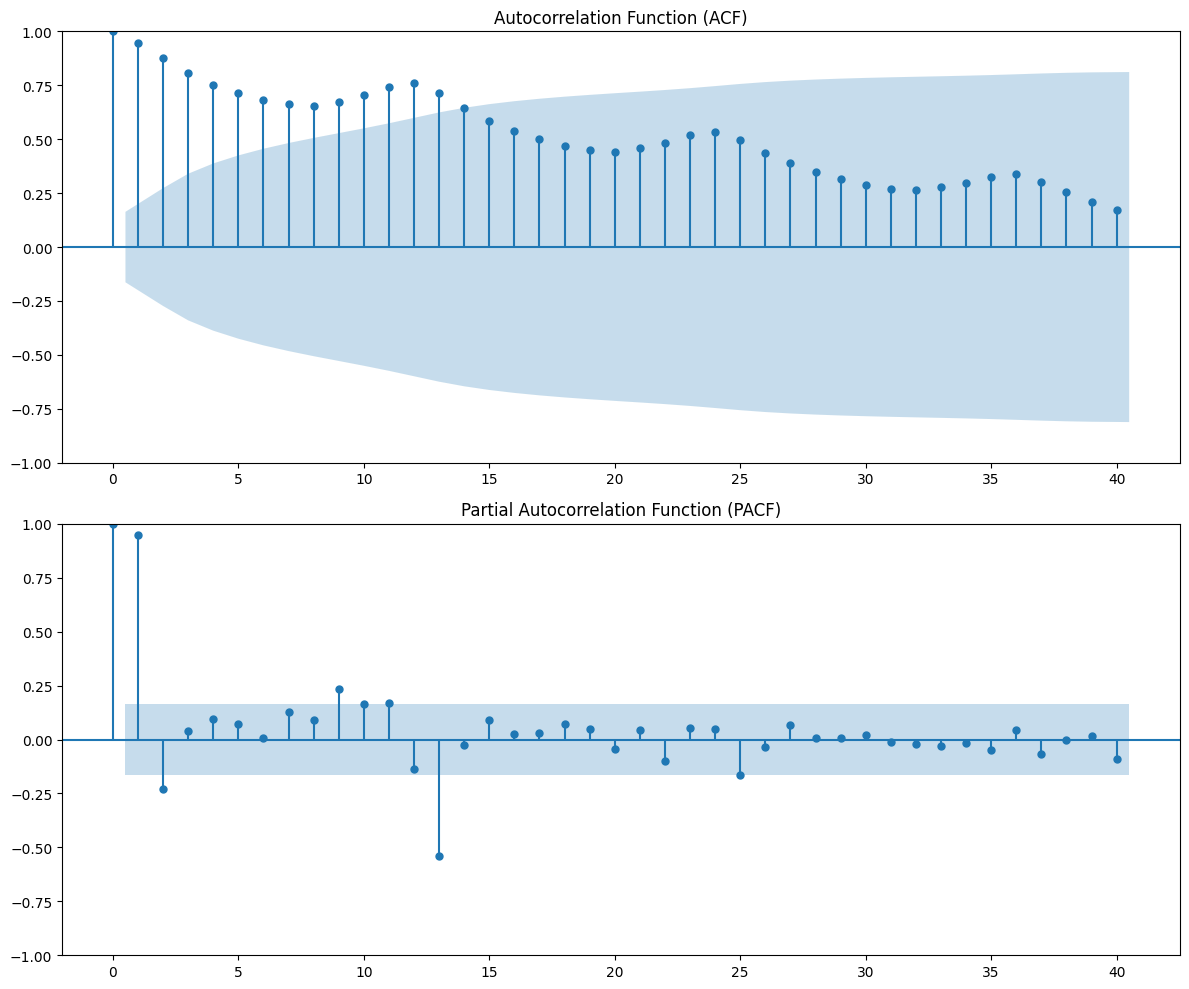

In [10]:
# --- 4. ACF and PACF Plots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF: Autocorrelation Function
plot_acf(ts_data, lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF)')

# PACF: Partial Autocorrelation Function
plot_pacf(ts_data, lags=40, ax=ax2, method='ywm')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()